In [2]:
from pathlib import Path
import gc
import json
import os
import time

import joblib
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from xgboost import XGBClassifier

PROJECT_DIR = Path(r"D:\Sami Data Set")

TRAIN_DIR = PROJECT_DIR / "data" / "splits" / "train"
TEST_DIR = PROJECT_DIR / "data" / "splits" / "test"

DOCUMENTATION_DIR = PROJECT_DIR / "documentation"
TABLES_DIR = PROJECT_DIR / "outputs" / "tables"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figures"
PREDICTIONS_DIR = PROJECT_DIR / "outputs" / "predictions"
MODELS_DIR = PROJECT_DIR / "models"

for directory in [
    DOCUMENTATION_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    MODELS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

CPU_COUNT = os.cpu_count() or 2
N_JOBS = max(1, CPU_COUNT - 1)

train_files = sorted(
    TRAIN_DIR.glob("*_train.parquet")
)

test_files = sorted(
    TEST_DIR.glob("*_test.parquet")
)

candidate_path = (
    DOCUMENTATION_DIR
    / "final_model_candidate.json"
)

selected_features_path = (
    DOCUMENTATION_DIR
    / "selected_feature_set.json"
)

validation_results_path = (
    TABLES_DIR
    / "tuned_model_outer_validation_results.csv"
)

print("CPU cores detected:", CPU_COUNT)
print("CPU cores to use:", N_JOBS)
print("Training files:", len(train_files))
print("Test files:", len(test_files))
print("Candidate file exists:", candidate_path.exists())
print(
    "Selected-features file exists:",
    selected_features_path.exists()
)
print(
    "Validation-results file exists:",
    validation_results_path.exists()
)

if len(train_files) != 10:
    raise FileNotFoundError(
        f"Expected 10 training files, found {len(train_files)}."
    )

if len(test_files) != 10:
    raise FileNotFoundError(
        f"Expected 10 test files, found {len(test_files)}."
    )

if not candidate_path.exists():
    raise FileNotFoundError(
        "Final model candidate file is missing."
    )

print("\nNotebook 10 setup completed.")

CPU cores detected: 2
CPU cores to use: 1
Training files: 10
Test files: 10
Candidate file exists: True
Selected-features file exists: True
Validation-results file exists: True

Notebook 10 setup completed.


In [3]:
with open(
    candidate_path,
    "r",
    encoding="utf-8"
) as candidate_file:
    final_candidate_information = json.load(
        candidate_file
    )

final_candidate_name = (
    final_candidate_information[
        "recommended_final_candidate"
    ]
)

selected_features = (
    final_candidate_information["features"]
)

rf_parameters = (
    final_candidate_information[
        "random_forest_parameters"
    ]
)

xgb_parameters = (
    final_candidate_information[
        "xgboost_parameters"
    ]
)

print("Final model candidate:", final_candidate_name)
print("Selected features:", len(selected_features))

for number, feature in enumerate(
    selected_features,
    start=1
):
    print(f"{number:02d}. {feature}")

if "Random Forest" in final_candidate_name:
    print("\nFinal algorithm: Random Forest")
    print("Parameters:", rf_parameters)

elif "XGBoost" in final_candidate_name:
    print("\nFinal algorithm: XGBoost")
    print("Parameters:", xgb_parameters)

else:
    raise ValueError(
        f"Unknown final model candidate: "
        f"{final_candidate_name}"
    )

Final model candidate: Tuned XGBoost
Selected features: 20
01. Fwd Packet Length Max
02. Init Bwd Win Bytes
03. Fwd Packet Length Std
04. Avg Fwd Segment Size
05. Init Fwd Win Bytes
06. Fwd Seg Size Min
07. Flow Duration
08. Flow IAT Max
09. Packet Length Variance
10. Subflow Fwd Bytes
11. Flow IAT Mean
12. Packet Length Mean
13. Packet Length Max
14. Avg Bwd Segment Size
15. Fwd IAT Std
16. Bwd Packet Length Std
17. Bwd Packet Length Max
18. Bwd Packets Length Total
19. Bwd IAT Min
20. RST Flag Count

Final algorithm: XGBoost
Parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 2, 'subsample': 0.85, 'colsample_bytree': 0.85}


In [4]:
schema_columns = pq.ParquetFile(
    train_files[0]
).schema.names

missing_features = [
    feature
    for feature in selected_features
    if feature not in schema_columns
]

if missing_features:
    raise KeyError(
        f"Selected features are missing: "
        f"{missing_features}"
    )

print("All selected features exist.")

All selected features exist.


In [5]:
training_file_information = []

for file_path in train_files:
    row_count = (
        pq.ParquetFile(
            file_path
        ).metadata.num_rows
    )

    training_file_information.append({
        "file_name": file_path.name,
        "rows": row_count
    })

test_file_information = []

for file_path in test_files:
    row_count = (
        pq.ParquetFile(
            file_path
        ).metadata.num_rows
    )

    test_file_information.append({
        "file_name": file_path.name,
        "rows": row_count
    })

training_inventory = pd.DataFrame(
    training_file_information
)

test_inventory = pd.DataFrame(
    test_file_information
)

total_training_rows = int(
    training_inventory["rows"].sum()
)

total_test_rows = int(
    test_inventory["rows"].sum()
)

estimated_training_memory_mb = (
    total_training_rows
    * len(selected_features)
    * 4
    / (1024 ** 2)
)

display(training_inventory)
display(test_inventory)

print(
    "Complete training records:",
    f"{total_training_rows:,}"
)

print(
    "Complete test records:",
    f"{total_test_rows:,}"
)

print(
    "Estimated predictor-array memory:",
    round(estimated_training_memory_mb, 2),
    "MB"
)

training_inventory.to_csv(
    DOCUMENTATION_DIR
    / "final_training_file_inventory.csv",
    index=False
)

test_inventory.to_csv(
    DOCUMENTATION_DIR
    / "final_test_file_inventory.csv",
    index=False
)

,file_name,rows
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,617270
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,495477
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,763877
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,449117
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,635849
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,473498
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,365498
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,199336
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,664179
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,663524


,file_name,rows
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,154317
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,123869
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,190969
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,112279
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,158963
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,118375
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,91375
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,49834
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,166045
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,165881


Complete training records: 5,327,625
Complete test records: 1,331,907
Estimated predictor-array memory: 406.47 MB


In [6]:
print(
    "Allocating the complete training arrays...",
    flush=True
)

X_train_full = np.empty(
    (
        total_training_rows,
        len(selected_features)
    ),
    dtype=np.float32
)

y_train_full = np.empty(
    total_training_rows,
    dtype=np.int8
)

current_position = 0

training_load_records = []

for file_number, file_path in enumerate(
    train_files,
    start=1
):
    print(
        f"[{file_number}/{len(train_files)}] "
        f"Loading {file_path.name}",
        flush=True
    )

    load_start = time.time()

    df = pd.read_parquet(
        file_path,
        columns=(
            selected_features
            + ["binary_label"]
        )
    )

    file_rows = len(df)

    next_position = (
        current_position + file_rows
    )

    X_batch = (
        df[selected_features]
        .to_numpy(
            dtype=np.float32,
            copy=True
        )
    )

    y_batch = (
        df["binary_label"]
        .to_numpy(
            dtype=np.int8,
            copy=True
        )
    )

    if not np.isfinite(X_batch).all():
        raise ValueError(
            f"Non-finite values found in "
            f"{file_path.name}."
        )

    X_train_full[
        current_position:next_position
    ] = X_batch

    y_train_full[
        current_position:next_position
    ] = y_batch

    training_load_records.append({
        "file_name": file_path.name,
        "rows_loaded": file_rows,
        "loading_seconds": round(
            time.time() - load_start,
            3
        )
    })

    current_position = next_position

    del df
    del X_batch
    del y_batch
    gc.collect()

if current_position != total_training_rows:
    raise ValueError(
        "The number of loaded records does not "
        "match the training inventory."
    )

print("\nComplete training partition loaded.")
print("Predictor shape:", X_train_full.shape)
print("Target shape:", y_train_full.shape)

print("\nTraining class distribution:")
unique_classes, class_counts = np.unique(
    y_train_full,
    return_counts=True
)

for class_value, class_count in zip(
    unique_classes,
    class_counts
):
    traffic_type = (
        "Benign"
        if class_value == 0
        else "Malicious"
    )

    print(
        traffic_type,
        ":",
        f"{class_count:,}"
    )

pd.DataFrame(
    training_load_records
).to_csv(
    DOCUMENTATION_DIR
    / "final_training_loading_log.csv",
    index=False
)

Allocating the complete training arrays...
[1/10] Loading Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_train.parquet
[2/10] Loading Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_train.parquet
[3/10] Loading DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_train.parquet
[4/10] Loading DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_train.parquet
[5/10] Loading DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_train.parquet
[6/10] Loading DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_train.parquet
[7/10] Loading Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_train.parquet
[8/10] Loading Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter_train.parquet
[9/10] Loading Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter_train.parquet
[10/10] Loading Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter_train.parquet

Complete training partition loaded.
Predictor shape: (5327625, 20)
Target shape: (5327625,)

Training class distribution:
Benign : 4,263,206
Mali

In [7]:
print(
    "Allocating the complete training arrays...",
    flush=True
)

X_train_full = np.empty(
    (
        total_training_rows,
        len(selected_features)
    ),
    dtype=np.float32
)

y_train_full = np.empty(
    total_training_rows,
    dtype=np.int8
)

current_position = 0

training_load_records = []

for file_number, file_path in enumerate(
    train_files,
    start=1
):
    print(
        f"[{file_number}/{len(train_files)}] "
        f"Loading {file_path.name}",
        flush=True
    )

    load_start = time.time()

    df = pd.read_parquet(
        file_path,
        columns=(
            selected_features
            + ["binary_label"]
        )
    )

    file_rows = len(df)

    next_position = (
        current_position + file_rows
    )

    X_batch = (
        df[selected_features]
        .to_numpy(
            dtype=np.float32,
            copy=True
        )
    )

    y_batch = (
        df["binary_label"]
        .to_numpy(
            dtype=np.int8,
            copy=True
        )
    )

    if not np.isfinite(X_batch).all():
        raise ValueError(
            f"Non-finite values found in "
            f"{file_path.name}."
        )

    X_train_full[
        current_position:next_position
    ] = X_batch

    y_train_full[
        current_position:next_position
    ] = y_batch

    training_load_records.append({
        "file_name": file_path.name,
        "rows_loaded": file_rows,
        "loading_seconds": round(
            time.time() - load_start,
            3
        )
    })

    current_position = next_position

    del df
    del X_batch
    del y_batch
    gc.collect()

if current_position != total_training_rows:
    raise ValueError(
        "The number of loaded records does not "
        "match the training inventory."
    )

print("\nComplete training partition loaded.")
print("Predictor shape:", X_train_full.shape)
print("Target shape:", y_train_full.shape)

print("\nTraining class distribution:")
unique_classes, class_counts = np.unique(
    y_train_full,
    return_counts=True
)

for class_value, class_count in zip(
    unique_classes,
    class_counts
):
    traffic_type = (
        
        "Benign"
        if class_value == 0
        else "Malicious"
    )

    print(
        traffic_type,
        ":",
        f"{class_count:,}"
    )

pd.DataFrame(
    training_load_records
).to_csv(
    DOCUMENTATION_DIR
    / "final_training_loading_log.csv",
    index=False
)


Allocating the complete training arrays...
[1/10] Loading Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_train.parquet
[2/10] Loading Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_train.parquet
[3/10] Loading DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_train.parquet
[4/10] Loading DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_train.parquet
[5/10] Loading DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_train.parquet
[6/10] Loading DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_train.parquet
[7/10] Loading Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_train.parquet
[8/10] Loading Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter_train.parquet
[9/10] Loading Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter_train.parquet
[10/10] Loading Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter_train.parquet

Complete training partition loaded.
Predictor shape: (5327625, 20)
Target shape: (5327625,)

Training class distribution:
Benign : 4,263,206
Mali

In [8]:
benign_training_count = int(
    np.sum(y_train_full == 0)
)

malicious_training_count = int(
    np.sum(y_train_full == 1)
)

scale_pos_weight = (
    benign_training_count
    / malicious_training_count
)

if "Random Forest" in final_candidate_name:

    final_model = RandomForestClassifier(
        n_estimators=int(
            rf_parameters["n_estimators"]
        ),
        max_depth=int(
            rf_parameters["max_depth"]
        ),
        min_samples_split=int(
            rf_parameters[
                "min_samples_split"
            ]
        ),
        min_samples_leaf=int(
            rf_parameters[
                "min_samples_leaf"
            ]
        ),
        max_features=rf_parameters[
            "max_features"
        ],
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=N_JOBS,
        verbose=1
    )

    final_algorithm = "Random Forest"

elif "XGBoost" in final_candidate_name:

    final_model = XGBClassifier(
        n_estimators=int(
            xgb_parameters["n_estimators"]
        ),
        max_depth=int(
            xgb_parameters["max_depth"]
        ),
        learning_rate=float(
            xgb_parameters["learning_rate"]
        ),
        min_child_weight=int(
            xgb_parameters[
                "min_child_weight"
            ]
        ),
        subsample=float(
            xgb_parameters["subsample"]
        ),
        colsample_bytree=float(
            xgb_parameters[
                "colsample_bytree"
            ]
        ),
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        n_jobs=N_JOBS
    )

    final_algorithm = "XGBoost"

print("Final algorithm:", final_algorithm)
print(
    "Training scale_pos_weight:",
    round(scale_pos_weight, 4)
)


Final algorithm: XGBoost
Training scale_pos_weight: 4.0052


In [9]:
print(
    f"Training final {final_algorithm} "
    f"on {total_training_rows:,} records...",
    flush=True
)

final_training_start = time.time()

final_model.fit(
    X_train_full,
    y_train_full
)

final_training_seconds = (
    time.time() - final_training_start
)

print("\nFinal model training completed.")
print(
    "Training time:",
    round(final_training_seconds, 2),
    "seconds"
)

final_model_path = (
    MODELS_DIR / "final_model.joblib"
)

joblib.dump(
    final_model,
    final_model_path
)

if final_algorithm == "XGBoost":
    final_model.save_model(
        MODELS_DIR / "final_xgboost_model.json"
    )

print("Final model saved to:")
print(final_model_path)

Training final XGBoost on 5,327,625 records...

Final model training completed.
Training time: 392.81 seconds
Final model saved to:
D:\Sami Data Set\models\final_model.joblib


In [10]:
del X_train_full
del y_train_full

gc.collect()

print(
    "Training arrays removed from memory. "
    "The final model remains loaded."
)

Training arrays removed from memory. The final model remains loaded.


In [11]:
print(
    "Beginning one-time final test evaluation...",
    flush=True
)

overall_tn = 0
overall_fp = 0
overall_fn = 0
overall_tp = 0

test_prediction_seconds = 0.0

y_test_all = np.empty(
    total_test_rows,
    dtype=np.int8
)

test_probabilities_all = np.empty(
    total_test_rows,
    dtype=np.float32
)

current_test_position = 0

file_result_records = []
attack_summary_parts = []
error_parts = []

for file_number, file_path in enumerate(
    test_files,
    start=1
):
    print(
        f"\n[{file_number}/{len(test_files)}] "
        f"Evaluating {file_path.name}",
        flush=True
    )

    test_df = pd.read_parquet(
        file_path,
        columns=(
            selected_features
            + [
                "binary_label",
                "original_attack_label",
                "source_file_id",
                "source_row_id"
            ]
        )
    )

    X_test_batch = (
        test_df[selected_features]
        .to_numpy(
            dtype=np.float32,
            copy=True
        )
    )

    y_test_batch = (
        test_df["binary_label"]
        .to_numpy(
            dtype=np.int8,
            copy=True
        )
    )

    prediction_start = time.time()

    test_predictions = (
        final_model.predict(
            X_test_batch
        ).astype(np.int8)
    )

    test_probabilities = (
        final_model.predict_proba(
            X_test_batch
        )[:, 1]
        .astype(np.float32)
    )

    file_prediction_seconds = (
        time.time() - prediction_start
    )

    test_prediction_seconds += (
        file_prediction_seconds
    )

    tn, fp, fn, tp = confusion_matrix(
        y_test_batch,
        test_predictions,
        labels=[0, 1]
    ).ravel()

    overall_tn += int(tn)
    overall_fp += int(fp)
    overall_fn += int(fn)
    overall_tp += int(tp)

    file_accuracy = accuracy_score(
        y_test_batch,
        test_predictions
    )

    file_precision = precision_score(
        y_test_batch,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    file_recall = recall_score(
        y_test_batch,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    file_f1 = f1_score(
        y_test_batch,
        test_predictions,
        pos_label=1,
        zero_division=0
    )

    file_result_records.append({
        "test_file": file_path.name,
        "records": len(test_df),
        "accuracy": file_accuracy,
        "malicious_precision":
            file_precision,
        "malicious_recall": file_recall,
        "malicious_f1": file_f1,
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "prediction_seconds": round(
            file_prediction_seconds,
            3
        )
    })

    next_test_position = (
        current_test_position
        + len(test_df)
    )

    y_test_all[
        current_test_position:
        next_test_position
    ] = y_test_batch

    test_probabilities_all[
        current_test_position:
        next_test_position
    ] = test_probabilities

    result_df = pd.DataFrame({
        "original_attack_label":
            test_df[
                "original_attack_label"
            ].astype(str),
        "actual_label":
            y_test_batch,
        "predicted_label":
            test_predictions
    })

    result_df["correct_prediction"] = (
        result_df["actual_label"]
        == result_df["predicted_label"]
    ).astype(int)

    result_df["true_positive"] = (
        (result_df["actual_label"] == 1)
        & (result_df["predicted_label"] == 1)
    ).astype(int)

    result_df["false_negative"] = (
        (result_df["actual_label"] == 1)
        & (result_df["predicted_label"] == 0)
    ).astype(int)

    result_df["false_positive"] = (
        (result_df["actual_label"] == 0)
        & (result_df["predicted_label"] == 1)
    ).astype(int)

    result_df["true_negative"] = (
        (result_df["actual_label"] == 0)
        & (result_df["predicted_label"] == 0)
    ).astype(int)

    attack_summary = (
        result_df
        .groupby(
            "original_attack_label",
            as_index=False
        )
        .agg(
            total_records=(
                "actual_label",
                "size"
            ),
            actual_malicious=(
                "actual_label",
                "sum"
            ),
            predicted_malicious=(
                "predicted_label",
                "sum"
            ),
            correct_predictions=(
                "correct_prediction",
                "sum"
            ),
            true_positives=(
                "true_positive",
                "sum"
            ),
            false_negatives=(
                "false_negative",
                "sum"
            ),
            false_positives=(
                "false_positive",
                "sum"
            ),
            true_negatives=(
                "true_negative",
                "sum"
            )
        )
    )

    attack_summary[
        "source_test_file"
    ] = file_path.name

    attack_summary_parts.append(
        attack_summary
    )

    error_mask = (
        y_test_batch != test_predictions
    )

    if error_mask.any():
        error_df = test_df.loc[
            error_mask,
            [
                "source_file_id",
                "source_row_id",
                "original_attack_label"
            ]
        ].copy()

        error_df["actual_label"] = (
            y_test_batch[error_mask]
        )

        error_df["predicted_label"] = (
            test_predictions[error_mask]
        )

        error_df[
            "malicious_probability"
        ] = test_probabilities[error_mask]

        error_df[
            "source_test_file"
        ] = file_path.name

        error_parts.append(error_df)

    print(
        f"Records: {len(test_df):,} | "
        f"F1: {file_f1:.4f} | "
        f"FP: {fp:,} | FN: {fn:,}",
        flush=True
    )

    current_test_position = (
        next_test_position
    )

    del test_df
    del X_test_batch
    del y_test_batch
    del test_predictions
    del test_probabilities
    del result_df
    del attack_summary

    gc.collect()

if current_test_position != total_test_rows:
    raise ValueError(
        "Test records evaluated do not match "
        "the test inventory."
    )

print("\nAll test files evaluated.")

Beginning one-time final test evaluation...

[1/10] Evaluating Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 154,317 | F1: 0.9925 | FP: 275 | FN: 161

[2/10] Evaluating Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 123,869 | F1: 0.9992 | FP: 31 | FN: 0

[3/10] Evaluating DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 190,969 | F1: 0.9999 | FP: 28 | FN: 2

[4/10] Evaluating DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 112,279 | F1: 1.0000 | FP: 1 | FN: 0

[5/10] Evaluating DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 158,963 | F1: 0.9876 | FP: 243 | FN: 14

[6/10] Evaluating DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 118,375 | F1: 1.0000 | FP: 1 | FN: 0

[7/10] Evaluating Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter_test.parquet
Records: 91,375 | F1: 0.1296 | FP: 2,974 | FN: 10,302

[8/10] Evaluating Infil2-

In [12]:
final_accuracy = (
    (overall_tp + overall_tn)
    / total_test_rows
)

final_precision = (
    overall_tp
    / (overall_tp + overall_fp)
    if (overall_tp + overall_fp) > 0
    else 0
)

final_recall = (
    overall_tp
    / (overall_tp + overall_fn)
    if (overall_tp + overall_fn) > 0
    else 0
)

final_f1 = (
    2
    * final_precision
    * final_recall
    / (final_precision + final_recall)
    if (
        final_precision + final_recall
    ) > 0
    else 0
)

final_false_positive_rate = (
    overall_fp
    / (overall_fp + overall_tn)
)

final_false_negative_rate = (
    overall_fn
    / (overall_fn + overall_tp)
)

final_roc_auc = roc_auc_score(
    y_test_all,
    test_probabilities_all
)

final_average_precision = (
    average_precision_score(
        y_test_all,
        test_probabilities_all
    )
)

final_test_results = pd.DataFrame([
    {
        "model": final_algorithm,
        "records_evaluated":
            total_test_rows,
        "number_of_features":
            len(selected_features),
        "classification_threshold":
            0.50,
        "accuracy": final_accuracy,
        "malicious_precision":
            final_precision,
        "malicious_recall":
            final_recall,
        "malicious_f1":
            final_f1,
        "roc_auc": final_roc_auc,
        "average_precision":
            final_average_precision,
        "false_positive_rate":
            final_false_positive_rate,
        "false_negative_rate":
            final_false_negative_rate,
        "true_negatives":
            overall_tn,
        "false_positives":
            overall_fp,
        "false_negatives":
            overall_fn,
        "true_positives":
            overall_tp,
        "training_seconds":
            round(
                final_training_seconds,
                3
            ),
        "test_prediction_seconds":
            round(
                test_prediction_seconds,
                3
            )
    }
])

display(final_test_results)

print("\nFINAL TEST PERFORMANCE")
print("----------------------")
print("Model:", final_algorithm)
print(
    "Records evaluated:",
    f"{total_test_rows:,}"
)
print(
    "Accuracy:",
    round(final_accuracy, 4)
)
print(
    "Malicious precision:",
    round(final_precision, 4)
)
print(
    "Malicious recall:",
    round(final_recall, 4)
)
print(
    "Malicious F1-score:",
    round(final_f1, 4)
)
print(
    "ROC-AUC:",
    round(final_roc_auc, 4)
)
print(
    "Average precision:",
    round(
        final_average_precision,
        4
    )
)
print(
    "False positives:",
    f"{overall_fp:,}"
)
print(
    "False negatives:",
    f"{overall_fn:,}"
)

final_test_results.to_csv(
    TABLES_DIR
    / "final_model_test_results.csv",
    index=False
)

,model,records_evaluated,number_of_features,classification_threshold,accuracy,malicious_precision,malicious_recall,malicious_f1,roc_auc,average_precision,false_positive_rate,false_negative_rate,true_negatives,false_positives,false_negatives,true_positives,training_seconds,test_prediction_seconds
0,XGBoost,1331907,20,0.5,0.980038,0.979185,0.919633,0.948475,0.988208,0.974639,0.004881,0.080367,1060600,5202,21386,244719,392.815,19.752



FINAL TEST PERFORMANCE
----------------------
Model: XGBoost
Records evaluated: 1,331,907
Accuracy: 0.98
Malicious precision: 0.9792
Malicious recall: 0.9196
Malicious F1-score: 0.9485
ROC-AUC: 0.9882
Average precision: 0.9746
False positives: 5,202
False negatives: 21,386


In [13]:
per_file_test_results = pd.DataFrame(
    file_result_records
)

display(per_file_test_results)

per_file_test_results.to_csv(
    TABLES_DIR
    / "final_test_results_by_file.csv",
    index=False
)

attack_results_raw = pd.concat(
    attack_summary_parts,
    ignore_index=True
)

attack_results = (
    attack_results_raw
    .groupby(
        "original_attack_label",
        as_index=False
    )
    .agg(
        total_records=(
            "total_records",
            "sum"
        ),
        actual_malicious=(
            "actual_malicious",
            "sum"
        ),
        predicted_malicious=(
            "predicted_malicious",
            "sum"
        ),
        correct_predictions=(
            "correct_predictions",
            "sum"
        ),
        true_positives=(
            "true_positives",
            "sum"
        ),
        false_negatives=(
            "false_negatives",
            "sum"
        ),
        false_positives=(
            "false_positives",
            "sum"
        ),
        true_negatives=(
            "true_negatives",
            "sum"
        )
    )
)

attack_results["traffic_type"] = np.where(
    attack_results["actual_malicious"] > 0,
    "Malicious",
    "Benign"
)

attack_results["accuracy"] = (
    attack_results["correct_predictions"]
    / attack_results["total_records"]
)

attack_results[
    "attack_detection_rate"
] = np.where(
    attack_results["actual_malicious"] > 0,
    attack_results["true_positives"]
    / attack_results["actual_malicious"],
    np.nan
)

attack_results[
    "benign_false_alarm_rate"
] = np.where(
    attack_results["actual_malicious"] == 0,
    attack_results["false_positives"]
    / attack_results["total_records"],
    np.nan
)

attack_results = attack_results.sort_values(
    [
        "traffic_type",
        "total_records"
    ],
    ascending=[
        False,
        False
    ]
)

display(attack_results)

attack_results.to_csv(
    TABLES_DIR
    / "final_test_results_by_attack_label.csv",
    index=False
)

if error_parts:
    final_errors = pd.concat(
        error_parts,
        ignore_index=True
    )

    final_errors.to_parquet(
        PREDICTIONS_DIR
        / "final_test_misclassifications.parquet",
        engine="pyarrow",
        compression="snappy",
        index=False
    )

    print(
        "Misclassified records saved:",
        f"{len(final_errors):,}"
    )
else:
    print("No misclassified records found.")

,test_file,records,accuracy,malicious_precision,malicious_recall,malicious_f1,true_negatives,false_positives,false_negatives,true_positives,prediction_seconds
0,Botnet-Friday-02-03-2018_TrafficForML_CICFlowM...,154317,0.997175,0.990524,0.994430,0.992473,125135,275,161,28746,2.322
1,Bruteforce-Wednesday-14-02-2018_TrafficForML_C...,123869,0.999750,0.998356,1.000000,0.999177,105018,31,0,18820,1.836
2,DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowM...,190969,0.999843,0.999757,0.999983,0.999870,75868,28,2,115071,2.825
3,DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlo...,112279,0.999991,0.999975,1.000000,0.999988,72160,1,0,40118,1.641
4,DoS1-Thursday-15-02-2018_TrafficForML_CICFlowM...,158963,0.998383,0.976839,0.998636,0.987617,148457,243,14,10249,2.321
5,DoS2-Friday-16-02-2018_TrafficForML_CICFlowMet...,118375,0.999992,0.999966,1.000000,0.999983,89323,1,0,29051,1.728
6,Infil1-Wednesday-28-02-2018_TrafficForML_CICFl...,91375,0.854709,0.249369,0.087511,0.129557,77111,2974,10302,988,1.392
7,Infil2-Thursday-01-03-2018_TrafficForML_CICFlo...,49834,0.752358,0.510891,0.124768,0.200557,35945,1482,10859,1548,0.730
8,Web1-Thursday-22-02-2018_TrafficForML_CICFlowM...,166045,0.999693,0.595506,0.779412,0.675159,165941,36,15,53,2.530
9,Web2-Friday-23-02-2018_TrafficForML_CICFlowMet...,165881,0.999011,0.364078,0.694444,0.477707,165642,131,33,75,2.427


,original_attack_label,total_records,actual_malicious,predicted_malicious,correct_predictions,true_positives,false_negatives,false_positives,true_negatives,traffic_type,accuracy,attack_detection_rate,benign_false_alarm_rate
6,DDoS attacks-LOIC-HTTP,115073,115073,115071,115071,115071,2,0,0,Malicious,0.999983,0.999983,NaN
4,DDOS attack-HOIC,39772,39772,39772,39772,39772,0,0,0,Malicious,1.000000,1.000000,NaN
8,DoS attacks-Hulk,29045,29045,29045,29045,29045,0,0,0,Malicious,1.000000,1.000000,NaN
1,Bot,28907,28907,28746,28746,28746,161,0,0,Malicious,0.994430,0.994430,NaN
12,Infilteration,23697,23697,2536,2536,2536,21161,0,0,Malicious,0.107018,0.107018,NaN
14,SSH-Bruteforce,18810,18810,18810,18810,18810,0,0,0,Malicious,1.000000,1.000000,NaN
7,DoS attacks-GoldenEye,8283,8283,8282,8282,8282,1,0,0,Malicious,0.999879,0.999879,NaN
10,DoS attacks-Slowloris,1980,1980,1967,1967,1967,13,0,0,Malicious,0.993434,0.993434,NaN
5,DDOS attack-LOIC-UDP,346,346,346,346,346,0,0,0,Malicious,1.000000,1.000000,NaN
2,Brute Force -Web,115,115,69,69,69,46,0,0,Malicious,0.600000,0.600000,NaN


Misclassified records saved: 26,588


In [14]:
validation_results = pd.read_csv(
    validation_results_path
)

matching_validation_results = (
    validation_results[
        validation_results["model"]
        == final_candidate_name
    ].copy()
)

if matching_validation_results.empty:
    print(
        "Exact validation model name not found."
    )
    display(validation_results)

else:
    validation_row = (
        matching_validation_results.iloc[0]
    )

    validation_test_comparison = pd.DataFrame([
        {
            "evaluation_stage":
                "Outer validation",
            "malicious_precision":
                validation_row[
                    "malicious_precision"
                ],
            "malicious_recall":
                validation_row[
                    "malicious_recall"
                ],
            "malicious_f1":
                validation_row[
                    "malicious_f1"
                ],
            "false_positive_rate":
                validation_row[
                    "false_positive_rate"
                ],
            "false_negative_rate":
                validation_row[
                    "false_negative_rate"
                ]
        },
        {
            "evaluation_stage":
                "Final untouched test",
            "malicious_precision":
                final_precision,
            "malicious_recall":
                final_recall,
            "malicious_f1":
                final_f1,
            "false_positive_rate":
                final_false_positive_rate,
            "false_negative_rate":
                final_false_negative_rate
        }
    ])

    validation_test_comparison[
        "f1_difference_from_validation"
    ] = (
        validation_test_comparison[
            "malicious_f1"
        ]
        - validation_row[
            "malicious_f1"
        ]
    )

    display(validation_test_comparison)

    validation_test_comparison.to_csv(
        TABLES_DIR
        / "validation_test_performance_comparison.csv",
        index=False
    )

,evaluation_stage,malicious_precision,malicious_recall,malicious_f1,false_positive_rate,false_negative_rate,f1_difference_from_validation
0,Outer validation,0.979341,0.921862,0.949733,0.004847,0.078138,0.000000
1,Final untouched test,0.979185,0.919633,0.948475,0.004881,0.080367,-0.001257


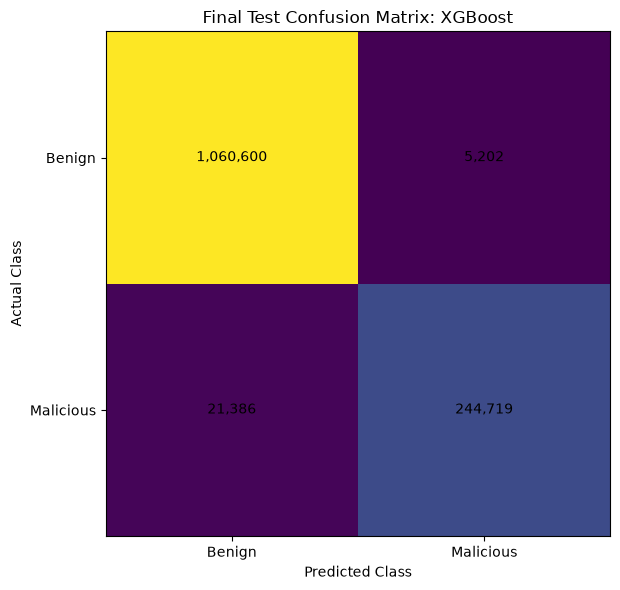

Confusion matrix saved to: D:\Sami Data Set\outputs\figures\final_test_confusion_matrix.png


In [15]:
final_confusion_matrix = np.array([
    [overall_tn, overall_fp],
    [overall_fn, overall_tp]
])

plt.figure(figsize=(7, 6))

plt.imshow(final_confusion_matrix)

plt.title(
    f"Final Test Confusion Matrix: "
    f"{final_algorithm}"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0, 1],
    ["Benign", "Malicious"]
)

plt.yticks(
    [0, 1],
    ["Benign", "Malicious"]
)

for row_number in range(2):
    for column_number in range(2):
        value = int(
            final_confusion_matrix[
                row_number,
                column_number
            ]
        )

        plt.text(
            column_number,
            row_number,
            f"{value:,}",
            ha="center",
            va="center"
        )

plt.tight_layout()

confusion_figure_path = (
    FIGURES_DIR
    / "final_test_confusion_matrix.png"
)

plt.savefig(
    confusion_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Confusion matrix saved to:",
    confusion_figure_path
)



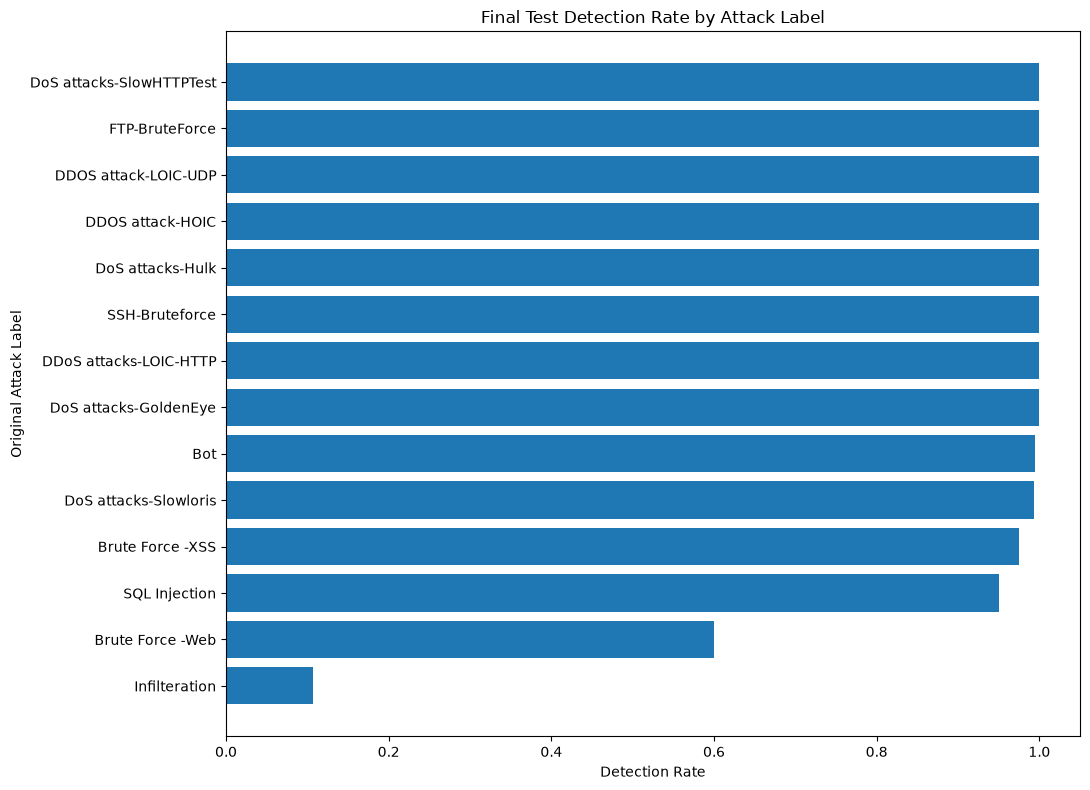

Attack-detection figure saved to: D:\Sami Data Set\outputs\figures\final_test_detection_rate_by_attack.png


In [16]:
malicious_attack_results = attack_results[
    attack_results["traffic_type"]
    == "Malicious"
].copy()

malicious_attack_results = (
    malicious_attack_results
    .sort_values(
        "attack_detection_rate",
        ascending=True
    )
)

plt.figure(
    figsize=(11, 8)
)

plt.barh(
    malicious_attack_results[
        "original_attack_label"
    ],
    malicious_attack_results[
        "attack_detection_rate"
    ]
)

plt.title(
    "Final Test Detection Rate by Attack Label"
)
plt.xlabel("Detection Rate")
plt.ylabel("Original Attack Label")
plt.xlim(0, 1.05)

plt.tight_layout()

attack_figure_path = (
    FIGURES_DIR
    / "final_test_detection_rate_by_attack.png"
)

plt.savefig(
    attack_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print(
    "Attack-detection figure saved to:",
    attack_figure_path
)

In [17]:
final_evaluation_information = {
    "final_algorithm":
        final_algorithm,
    "selected_features":
        selected_features,
    "number_of_features":
        len(selected_features),
    "training_records":
        total_training_rows,
    "test_records":
        total_test_rows,
    "classification_threshold":
        0.50,
    "accuracy":
        float(final_accuracy),
    "malicious_precision":
        float(final_precision),
    "malicious_recall":
        float(final_recall),
    "malicious_f1":
        float(final_f1),
    "roc_auc":
        float(final_roc_auc),
    "average_precision":
        float(final_average_precision),
    "false_positives":
        int(overall_fp),
    "false_negatives":
        int(overall_fn),
    "training_seconds":
        float(final_training_seconds),
    "test_prediction_seconds":
        float(test_prediction_seconds),
    "test_set_evaluation_count":
        1,
    "post_test_tuning_permitted":
        False,
    "random_seed":
        RANDOM_SEED
}

with open(
    DOCUMENTATION_DIR
    / "final_model_evaluation.json",
    "w",
    encoding="utf-8"
) as evaluation_file:
    json.dump(
        final_evaluation_information,
        evaluation_file,
        indent=4
    )

summary_text = f"""
Final Model Evaluation Summary

The final {final_algorithm} model was trained using
{total_training_rows:,} records and {len(selected_features)}
selected network-flow features. It was evaluated once on the
untouched test partition containing {total_test_rows:,} records.

The model achieved an accuracy of {final_accuracy:.4f},
malicious-class precision of {final_precision:.4f}, recall of
{final_recall:.4f}, and F1-score of {final_f1:.4f}. Its ROC-AUC
was {final_roc_auc:.4f}, while average precision was
{final_average_precision:.4f}.

The final confusion matrix contained {overall_tn:,} true
negatives, {overall_fp:,} false positives, {overall_fn:,} false
negatives, and {overall_tp:,} true positives. No model,
feature-selection or threshold changes were made after the test
results were observed.
""".strip()

print(summary_text)

with open(
    DOCUMENTATION_DIR
    / "final_test_evaluation_summary.txt",
    "w",
    encoding="utf-8"
) as summary_file:
    summary_file.write(summary_text)

print("\nFinal evaluation documentation saved.")

Final Model Evaluation Summary

The final XGBoost model was trained using
5,327,625 records and 20
selected network-flow features. It was evaluated once on the
untouched test partition containing 1,331,907 records.

The model achieved an accuracy of 0.9800,
malicious-class precision of 0.9792, recall of
0.9196, and F1-score of 0.9485. Its ROC-AUC
was 0.9882, while average precision was
0.9746.

The final confusion matrix contained 1,060,600 true
negatives, 5,202 false positives, 21,386 false
negatives, and 244,719 true positives. No model,
feature-selection or threshold changes were made after the test
results were observed.

Final evaluation documentation saved.


## Final Model and Test-Evaluation Conclusion

The final model was trained using the complete frozen training
partition and the feature set selected through training-only analysis.
The model algorithm and hyperparameters were fixed before the test
partition was opened.

The final test partition was evaluated once using a classification
threshold of 0.50. Performance was assessed using malicious-class
precision, recall and F1-score, supported by accuracy, ROC-AUC,
average precision, false-positive and false-negative rates, and the
confusion matrix.

Performance was also examined separately for the original attack
labels to identify attack categories that were detected reliably and
those associated with false-negative errors. The final test results
were retained without further feature selection, threshold adjustment
or hyperparameter tuning.